# Pacotes Necessários

In [ ]:
install.packages("quantmod")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



# Baixando os dados das ações

In [ ]:
library(quantmod)

tickers <- c("PETR3.SA", "VALE3.SA", "ABEV3.SA", "BBAS3.SA")

data_fim <- Sys.Date()
data_inicio <- data_fim - 365

precos <- list()

for (t in tickers) {
  precos[[t]] <- getSymbols(t, src = "yahoo",
                             from = data_inicio, to = data_fim,
                             auto.assign = FALSE)
}

# Exemplo de acesso:
head(precos[["PETR3.SA"]])

           PETR3.SA.Open PETR3.SA.High PETR3.SA.Low PETR3.SA.Close
2025-06-18         36.06         36.27        35.54          35.75
2025-06-20         35.65         36.27        35.57          35.91
2025-06-23         36.30         36.52        34.74          34.90
2025-06-24         34.20         34.81        33.90          34.17
2025-06-25         34.09         34.40        33.96          33.97
2025-06-26         34.24         34.35        34.03          34.22
           PETR3.SA.Volume PETR3.SA.Adjusted
2025-06-18         7821800          33.07422
2025-06-20        23960500          33.22224
2025-06-23        13582300          32.28784
2025-06-24        17817000          31.61247
2025-06-25         9869200          31.42744
2025-06-26         6070400          31.65874

In [ ]:
precos[["VALE3.SA"]]

           VALE3.SA.Open VALE3.SA.High VALE3.SA.Low VALE3.SA.Close
2025-06-18         53.63         53.89        51.08          51.24
2025-06-20         51.24         51.28        49.92          49.92
2025-06-23         50.02         50.55        49.83          50.55
2025-06-24         50.74         50.75        50.14          50.54
2025-06-25         50.25         50.60        49.72          50.48
2025-06-26         50.84         52.30        50.84          52.00
2025-06-27         52.19         53.09        51.91          52.87
2025-06-30         52.79         53.03        52.44          52.65
2025-07-01         52.60         53.71        52.50          53.36
2025-07-02         53.81         55.70        53.80          55.30
       ...                                                        
2026-06-03         83.61         83.79        81.79          81.79
2026-06-05         80.79         80.79        78.33          78.70
2026-06-08         78.92         79.28        77.32          7

# Escrevendo o `.csv`

In [ ]:
# Após montar o objeto fechamentos

fechamentos_df <- data.frame(
  data = index(fechamentos),
  coredata(fechamentos)
)

write.csv(
  fechamentos_df,
  "acoes_b3_12m.csv",
  row.names = FALSE
)

In [ ]:
fechamentos_df <- read.csv("acoes_b3_12m.csv")

# Calculo de Retornos

In [ ]:
retornos <- diff(log(fechamentos))
retornos <- na.omit(retornos)

# Calcular μ e σ

In [ ]:
mu <- colMeans(retornos)

sigma <- apply(retornos, 2, sd)

# Verificando Normalidade

In [ ]:
ativos <- colnames(retornos)

resultado_normalidade <- data.frame()

for(i in 1:ncol(retornos)) {

  teste <- shapiro.test(as.numeric(retornos[,i]))

  resultado_normalidade <- rbind(

  resultado_normalidade,

  data.frame(

  Ativo = ativos[i],

  W = teste$statistic,

  p_valor = teste$p.value

)

)

}

resultado_normalidade

,Ativo,W,p_valor
,<chr>,<dbl>,<dbl>
W,Petrobras,0.9648188,8.787070e-06
W1,Vale,0.9766598,4.198619e-04
W2,Ambev,0.8326797,1.184249e-15
W3,Banco do Brasil,0.9746667,2.078314e-04


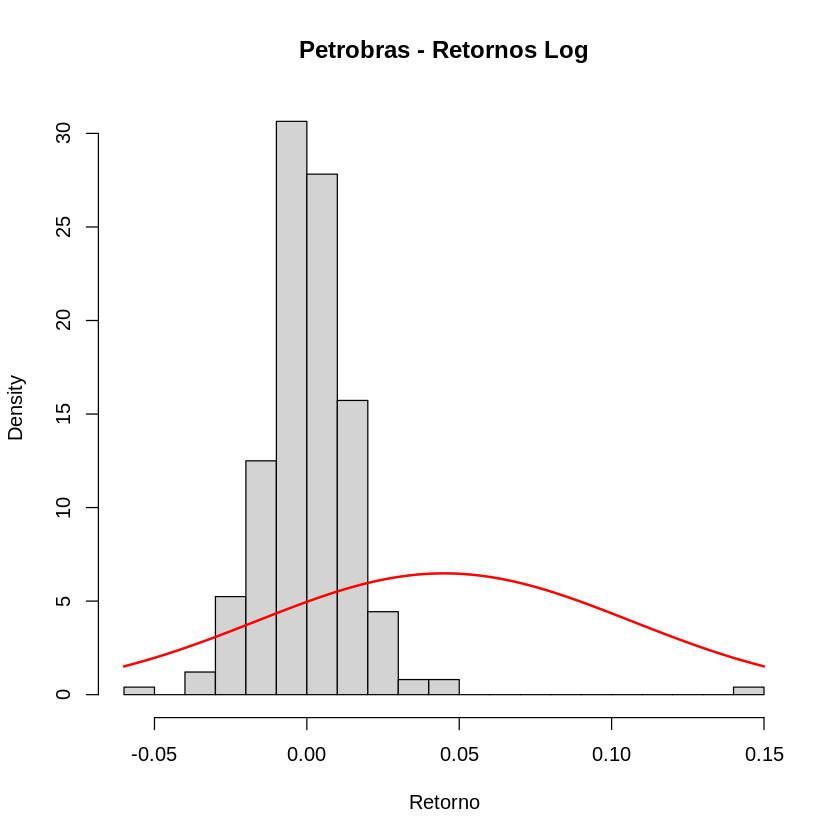

In [ ]:
x <- as.numeric(retornos[,3])

hist(
  x,
  probability = TRUE,
  breaks = 20,
  main = "Petrobras - Retornos Log",
  xlab = "Retorno"
)

curve(
  dnorm(x, mean(x), sd(x)),
  add = TRUE,
  lwd = 2,
  col = "red"
)

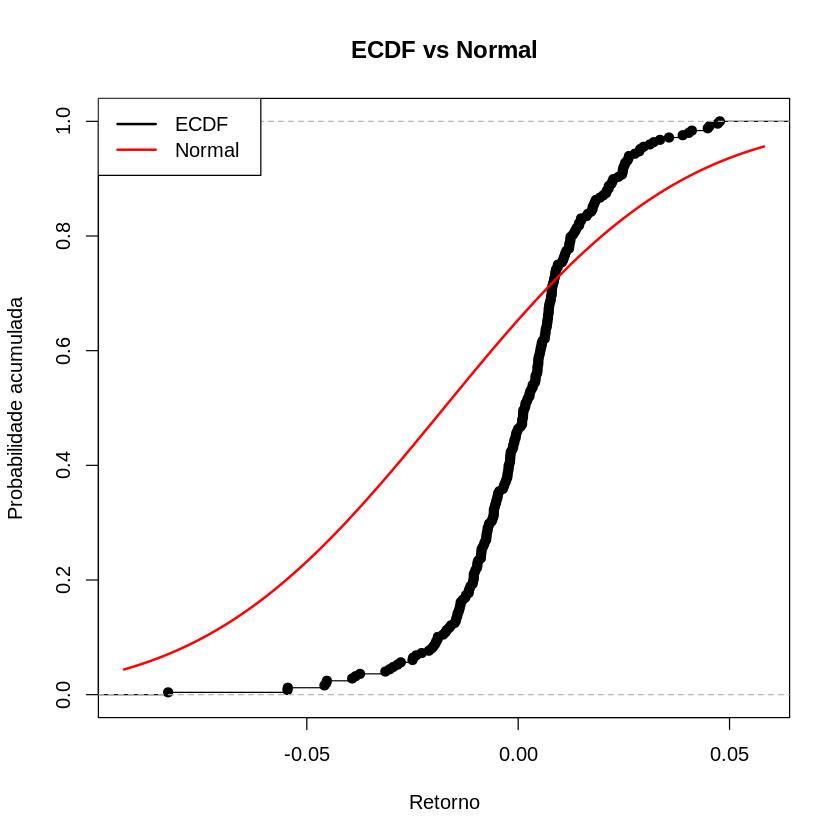

In [ ]:
x <- as.numeric(retornos[,1])

plot(
  ecdf(x),
  main = "ECDF vs Normal",
  xlab = "Retorno",
  ylab = "Probabilidade acumulada"
)

curve(
  pnorm(x, mean(x), sd(x)),
  add = TRUE,
  col = "red",
  lwd = 2
)

legend(
  "topleft",
  legend = c("ECDF", "Normal"),
  col = c("black", "red"),
  lwd = 2
)

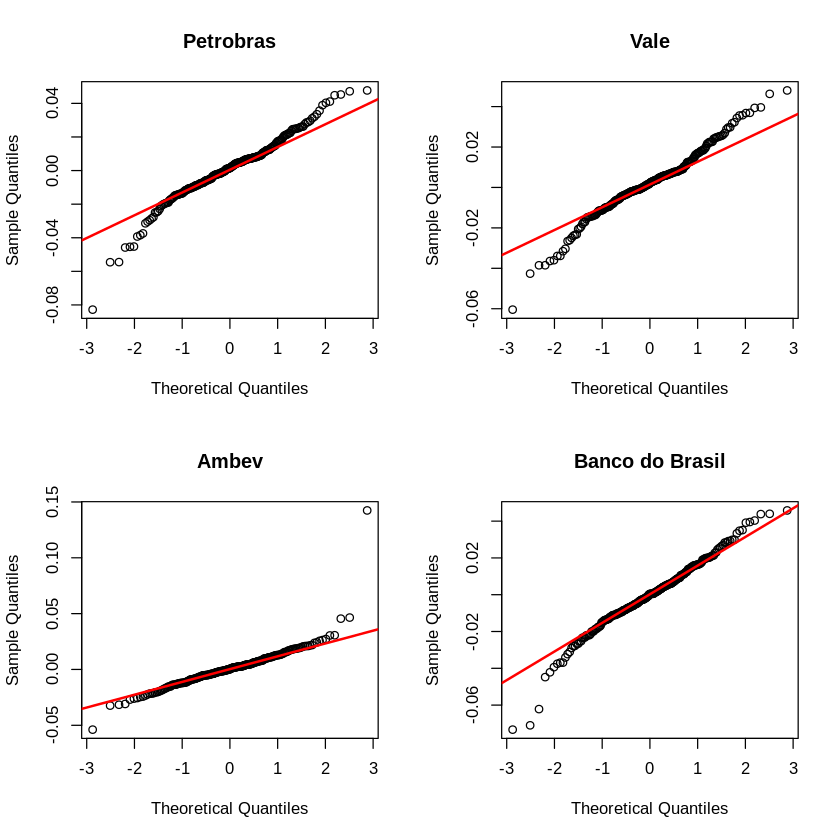

In [ ]:
par(mfrow = c(2,2))

for(i in 1:ncol(retornos)){

  x <- as.numeric(retornos[,i])

  qqnorm(
    x,
    main = colnames(retornos)[i]
  )

  qqline(
    x,
    col = "red",
    lwd = 2
  )
}

# Matriz de Correlação

In [ ]:
correlacao <- cor(retornos)
correlacao

,Petrobras,Vale,Ambev,Banco do Brasil
Petrobras,1.00000000,-0.0638041,0.02468481,0.1079665
Vale,-0.06380410,1.0000000,0.20568305,0.3595484
Ambev,0.02468481,0.2056830,1.00000000,0.3993957
Banco do Brasil,0.10796648,0.3595484,0.39939575,1.0000000


# Rascunhos

In [ ]:
library(quantmod)

tickers <- c("PETR3.SA", "VALE3.SA", "ABEV3.SA", "BBAS3.SA")

data_fim <- Sys.Date()
data_inicio <- data_fim - 365

precos <- list()

for (t in tickers) {
  precos[[t]] <- getSymbols(t, src = "yahoo",
                             from = data_inicio, to = data_fim,
                             auto.assign = FALSE)
}

# Combinar os preços de fechamento ajustados em um único data frame
fechamentos <- do.call(merge, lapply(precos, Ad))
colnames(fechamentos) <- c("Petrobras", "Vale", "Ambev", "Banco do Brasil")

head(fechamentos)
tail(fechamentos)

           Petrobras     Vale    Ambev Banco do Brasil
2025-06-18  33.07422 47.04032 12.89720        21.31007
2025-06-20  33.22224 45.82850 12.93544        20.86061
2025-06-23  32.28784 46.40687 12.96412        20.60657
2025-06-24  31.61248 46.39769 12.91632        20.94855
2025-06-25  31.42745 46.34261 12.57214        20.77267
2025-06-26  31.65874 47.73803 12.73467        21.10488

           Petrobras  Vale Ambev Banco do Brasil
2026-06-10     46.81 77.70 16.28           19.00
2026-06-11     46.80 78.80 16.64           19.41
2026-06-12     46.19 79.17 16.61           19.46
2026-06-15     43.74 81.16 16.57           19.39
2026-06-16     43.32 81.44 16.44           19.40
2026-06-17     43.07 79.78 16.19           19.41